In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# Install packages including EMD-signal for EMD/EEMD
!pip install PyWavelets --quiet
!pip install scikit-learn --quiet
!pip install scikit-posthocs --quiet
!pip install matplotlib --quiet
!pip install pandas --quiet
!pip install seaborn --quiet
!pip install EMD-signal --quiet

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.8/76.8 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.2/82.2 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.0/120.0 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 150.3/150.3 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.8/56.8 kB 3.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
datasets 4.0.0 requires dill<0.3.9,>=0.3.0, but you have dill 0.4.1 which is incompatible.
datasets 4.0.0 requires multiprocess<0.70.17, but you have multiprocess 0.70.19 which is incompatible.


In [ ]:
import os
from glob import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.signal import find_peaks
import pywt
from PyEMD import EMD, EEMD
from sklearn.decomposition import FastICA
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import scikit_posthocs as sp
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

In [ ]:
window_before = 90
window_after  = 120

# Replace with your Google Drive paths
diabetes_dir = '/content/drive/MyDrive/datasets_v2/diabetes'
normal_dir   = '/content/drive/MyDrive/datasets_v2/normal'

print("Parameters and paths set.")

Parameters and paths set.


In [ ]:
def denoise(data):
    # Replaced 'sym4' with 'db4' for better ECG morphology matching
    wavelet_type = 'db4'
    w = pywt.Wavelet(wavelet_type)
    maxlev = pywt.dwt_max_level(len(data), w.dec_len)
    threshold = 0.04

    coeffs = pywt.wavedec(data, wavelet_type, level=maxlev)
    for i in range(1, len(coeffs)):
        coeffs[i] = pywt.threshold(coeffs[i], threshold * max(coeffs[i]))

    datarec = pywt.waverec(coeffs, wavelet_type)
    return datarec

def extract_eemd_features(window_signal):
    # Initialize EEMD
    eemd = EEMD()
    # Keep trials relatively low to manage computation time across thousands of windows
    eemd.trials = 10

    # Execute EEMD to get IMFs (Intrinsic Mode Functions)
    imfs = eemd.eemd(window_signal)

    # Extract the standard deviation of the first 3 IMFs as features
    imf_features = []
    for i in range(min(3, len(imfs))):
        imf_features.append(np.std(imfs[i]))

    # Pad with zeros if fewer than 3 IMFs are generated
    while len(imf_features) < 3:
        imf_features.append(0.0)

    return imf_features[0], imf_features[1], imf_features[2]

In [ ]:
def process_ecg_folder(folder_path, label, column_name):
    print(f"\nProcessing folder: {folder_path}")
    csv_files = glob(os.path.join(folder_path, '*.csv'))
    print(f"Found {len(csv_files)} CSV files.")
    results = []

    for i, file in enumerate(csv_files, 1):
        df = pd.read_csv(file)

        if column_name not in df.columns:
            print(f"Skipping {file}, column {column_name} not found")
            continue

        ecg_signal = df[column_name].values
        denoised_signal = denoise(ecg_signal)
        normalized_signal = stats.zscore(denoised_signal)

        r_peaks, _ = find_peaks(normalized_signal, height=0.5, distance=150)
        if len(r_peaks) == 0:
            continue

        for r_peak in r_peaks:
            start = max(0, r_peak - window_before)
            end   = min(len(normalized_signal), r_peak + window_after)
            window_signal = normalized_signal[start:end]

            # Skip incomplete windows at the edges
            if len(window_signal) != (window_before + window_after):
                continue

            # Compute EEMD features for the window
            imf1_std, imf2_std, imf3_std = extract_eemd_features(window_signal)

            results.append({
                'file': os.path.basename(file),
                'window_signal': window_signal,
                'standard_deviation': np.std(window_signal),
                'imf1_std': imf1_std,
                'imf2_std': imf2_std,
                'imf3_std': imf3_std,
                'diabetes': label
            })
        print(f"Processed {i}/{len(csv_files)} files, extracted {len(r_peaks)} windows from {os.path.basename(file)}")

    df_out = pd.DataFrame(results)
    if df_out.empty:
        return df_out

    df_out = df_out.dropna().reset_index(drop=True)
    print(f"Total windows processed: {len(df_out)}")
    return df_out

# Process datasets
# Note: This step will take longer than before due to the EEMD computation
diabetes_df = process_ecg_folder(diabetes_dir, label=1, column_name='day')
normal_df   = process_ecg_folder(normal_dir, label=0, column_name='filtered')

# Combine
df = pd.concat([diabetes_df, normal_df], ignore_index=True)
print(f"\nCombined dataset shape: {df.shape}")


Processing folder: /content/drive/MyDrive/datasets_v2/diabetes
Found 43 CSV files.
Processed 1/43 files, extracted 535 windows from 19082406.csv
Processed 2/43 files, extracted 623 windows from 20121718.csv
Processed 3/43 files, extracted 738 windows from 20011712.csv
Processed 4/43 files, extracted 755 windows from 19072938.csv
Processed 5/43 files, extracted 679 windows from 19120723.csv
Processed 6/43 files, extracted 905 windows from 19090308.csv
Processed 7/43 files, extracted 809 windows from 19102622.csv
Processed 8/43 files, extracted 791 windows from 19121303.csv
Processed 9/43 files, extracted 763 windows from 19102524.csv
Processed 10/43 files, extracted 860 windows from 19102102.csv
Processed 11/43 files, extracted 703 windows from 19101619.csv
Processed 12/43 files, extracted 721 windows from 19121735.csv
Processed 13/43 files, extracted 728 windows from 20050628.csv
Processed 14/43 files, extracted 812 windows from 20122932.csv
Processed 15/43 files, extracted 705 window

In [ ]:
print("\nPerforming ICA decomposition...")
window_signals = np.vstack(df['window_signal'].values).astype(np.float32)

n_components = 48
ica = FastICA(n_components=n_components, random_state=42)
X_ica = ica.fit_transform(window_signals)

ica_df = pd.DataFrame(X_ica, columns=[f'ica_{i+1}' for i in range(n_components)])
df = df.reset_index(drop=True)
ica_df = ica_df.reset_index(drop=True)

# Combine ICA features, Standard Deviation, and the new EEMD features
df_final = pd.concat([ica_df, df[['imf1_std', 'imf2_std', 'imf3_std', 'standard_deviation', 'diabetes']]], axis=1)

print("ICA decomposition completed. Feature matrix shape:", df_final.shape)


Performing ICA decomposition...
ICA decomposition completed. Feature matrix shape: (56301, 50)


In [ ]:
# Add this to a new cell in your notebook
# We will sample the data if it's too large for quick Power BI loading,
# but 56k rows is fine for Power BI.
df_final.to_csv('ecg_features_for_powerbi.csv', index=False)

from google.colab import files
files.download('ecg_features_for_powerbi.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
X = df_final.drop(columns=['diabetes']).values
y = df_final['diabetes'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train samples: {len(X_train)}, Test samples: {len(X_test)}")

print("\nTraining KNN classifier...")
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"KNN Test Accuracy: {accuracy*100:.2f}%")
print(classification_report(y_test, y_pred))

Train samples: 45040, Test samples: 11261


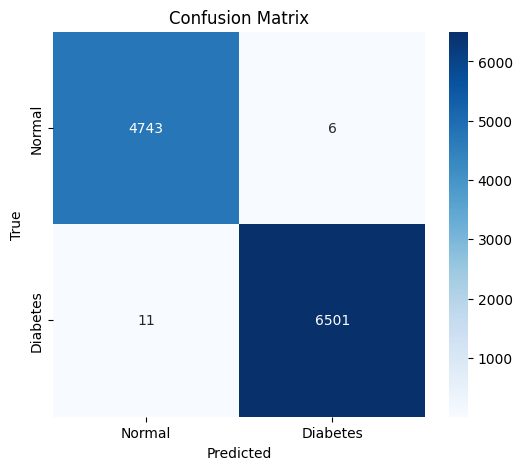

In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", xticklabels=["Normal", "Diabetes"], yticklabels=["Normal", "Diabetes"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


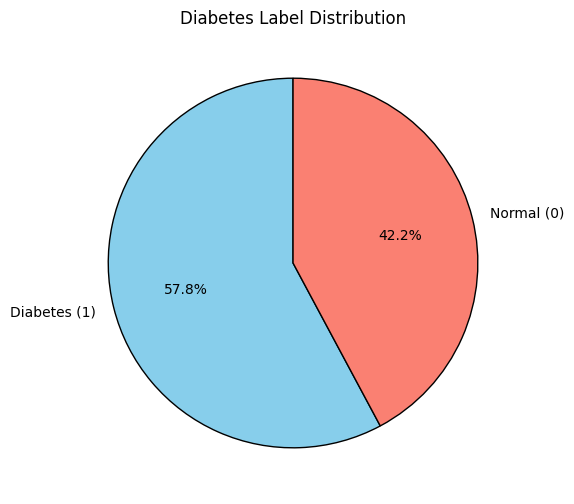

In [ ]:
label_counts = df_final['diabetes'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(label_counts, labels=['Diabetes (1)', 'Normal (0)'], autopct='%1.1f%%',
        colors=['skyblue', 'salmon'], startangle=90, wedgeprops={'edgecolor':'black'})
plt.title("Diabetes Label Distribution")
plt.show()


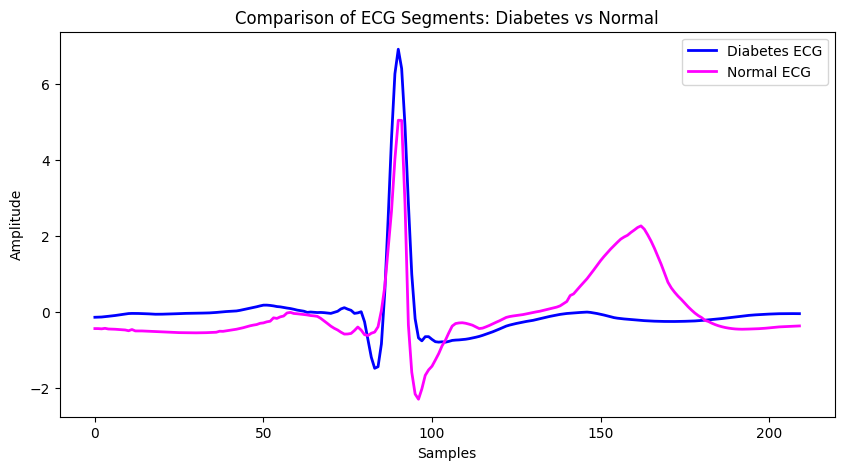

In [ ]:
diabetes_signal = stats.zscore(denoise(diabetes_df.iloc[0].window_signal))
normal_signal   = stats.zscore(denoise(normal_df.iloc[0].window_signal))

plt.figure(figsize=(10,5))
plt.plot(diabetes_signal, label='Diabetes ECG', color='blue', linewidth=2)
plt.plot(normal_signal, label='Normal ECG', color='magenta', linewidth=2)
plt.legend()
plt.title("Comparison of ECG Segments: Diabetes vs Normal")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.show()


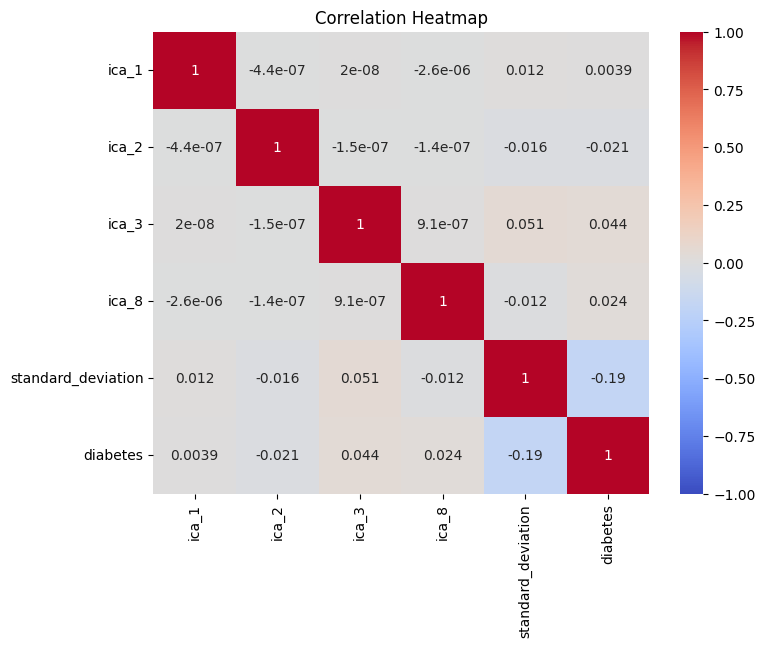

In [ ]:
correlation_matrix = df_final.corr(numeric_only=True)
selected_rows = ["ica_1","ica_2","ica_3","ica_8","standard_deviation","diabetes"]
corr_submatrix = correlation_matrix.loc[selected_rows, selected_rows]

plt.figure(figsize=(8,6))
sns.heatmap(corr_submatrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation Heatmap")
plt.show()


In [ ]:
diabetes_data = df_final[df_final['diabetes']==1].drop(columns=['diabetes'])
normal_data   = df_final[df_final['diabetes']==0].drop(columns=['diabetes'])

kruskal_results = {}
for column in diabetes_data.columns:
    stat, p_val = stats.kruskal(diabetes_data[column], normal_data[column])
    kruskal_results[column] = p_val
    if p_val < 0.05:
        print(f"{column} - significant (p={p_val:.5f})")

significant_columns = [col for col, p in kruskal_results.items() if p<0.05]

# Dunn's post-hoc
dunn_results = {}
for col in significant_columns:
    data = [diabetes_data[col].values, normal_data[col].values]
    dunn_results[col] = sp.posthoc_dunn(data)

print("\nDunn test results for significant features:")
for col, table in dunn_results.items():
    print(f"\n{col}:\n", table)


ica_1 - significant (p=0.00000)
ica_2 - significant (p=0.00000)
ica_3 - significant (p=0.00019)
ica_4 - significant (p=0.00000)
ica_5 - significant (p=0.00000)
ica_6 - significant (p=0.00000)
ica_7 - significant (p=0.00000)
ica_10 - significant (p=0.00000)
ica_11 - significant (p=0.00000)
ica_12 - significant (p=0.00000)
ica_13 - significant (p=0.00000)
ica_14 - significant (p=0.00000)
ica_15 - significant (p=0.00000)
ica_16 - significant (p=0.00000)
ica_17 - significant (p=0.00002)
ica_18 - significant (p=0.00036)
ica_19 - significant (p=0.00423)
ica_20 - significant (p=0.00000)
ica_21 - significant (p=0.00000)
ica_22 - significant (p=0.00000)
ica_23 - significant (p=0.04545)
ica_24 - significant (p=0.00000)
ica_25 - significant (p=0.00000)
ica_26 - significant (p=0.00000)
ica_27 - significant (p=0.00000)
ica_28 - significant (p=0.00000)
ica_29 - significant (p=0.00000)
ica_30 - significant (p=0.00000)
ica_31 - significant (p=0.00001)
ica_32 - significant (p=0.00000)
ica_33 - signific

In [ ]:
train_acc = accuracy_score(y_train, knn.predict(X_train))
test_acc = accuracy_score(y_test, y_pred)
print(f"Train Accuracy: {train_acc*100:.2f}%")
print(f"Test Accuracy: {test_acc*100:.2f}%")


Train Accuracy: 99.88%
Test Accuracy: 99.85%



Training SVM classifier...
SVM Test Accuracy: 99.84%

SVM Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      4749
           1       1.00      1.00      1.00      6512

    accuracy                           1.00     11261
   macro avg       1.00      1.00      1.00     11261
weighted avg       1.00      1.00      1.00     11261



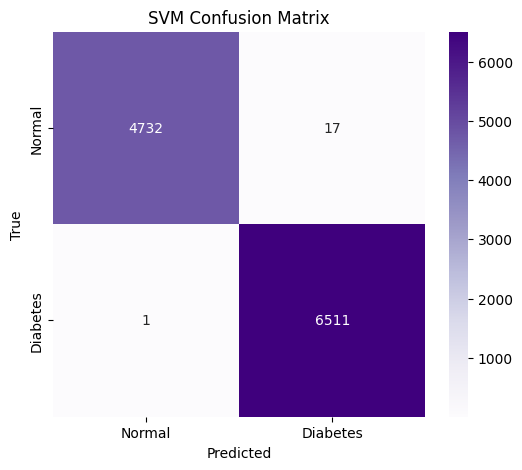

KNN Test Accuracy: 99.85%
SVM Test Accuracy: 99.84%
✅ KNN performed better than SVM.


In [ ]:

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

print("\nTraining SVM classifier...")

# Step 1: Feature Scaling (important for SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 2: Create and train the SVM model
svm = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm.fit(X_train_scaled, y_train)

# Step 3: Make predictions
y_pred_svm = svm.predict(X_test_scaled)

# Step 4: Evaluate SVM model
svm_accuracy = accuracy_score(y_test, y_pred_svm)
print(f"SVM Test Accuracy: {svm_accuracy * 100:.2f}%\n")
print("SVM Classification Report:\n", classification_report(y_test, y_pred_svm))

# Step 5: Confusion matrix for SVM
cm_svm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(6,5))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap="Purples",
            xticklabels=["Normal", "Diabetes"], yticklabels=["Normal", "Diabetes"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("SVM Confusion Matrix")
plt.show()

# Step 6: Compare accuracies
print(f"KNN Test Accuracy: {accuracy * 100:.2f}%")
print(f"SVM Test Accuracy: {svm_accuracy * 100:.2f}%")

if svm_accuracy > accuracy:
    print("✅ SVM performed better than KNN.")
else:
    print("✅ KNN performed better than SVM.")


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

Decision Tree Test Accuracy: 98.45%

Decision Tree Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.99      0.98      4749
           1       0.99      0.98      0.99      6512

    accuracy                           0.98     11261
   macro avg       0.98      0.98      0.98     11261
weighted avg       0.98      0.98      0.98     11261



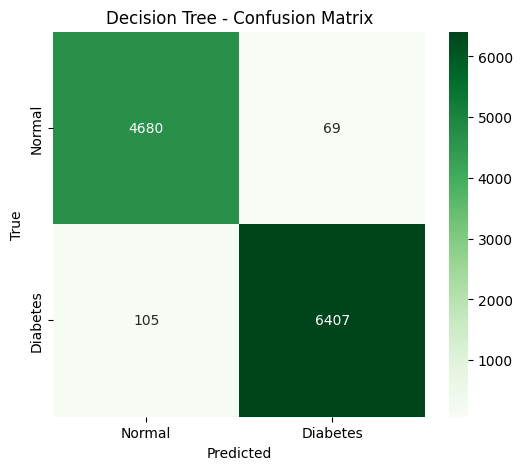

In [ ]:
dt = DecisionTreeClassifier(
    criterion='gini',
    max_depth=None,
    random_state=42
)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

dt_acc = accuracy_score(y_test, y_pred_dt)
print(f"Decision Tree Test Accuracy: {dt_acc*100:.2f}%")
print("\nDecision Tree Classification Report:\n", classification_report(y_test, y_pred_dt))

# Confusion Matrix
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred_dt), annot=True, fmt='d',
            cmap="Greens", xticklabels=["Normal","Diabetes"], yticklabels=["Normal","Diabetes"])
plt.title("Decision Tree - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


Random Forest Test Accuracy: 99.86%

Random Forest Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      4749
           1       1.00      1.00      1.00      6512

    accuracy                           1.00     11261
   macro avg       1.00      1.00      1.00     11261
weighted avg       1.00      1.00      1.00     11261



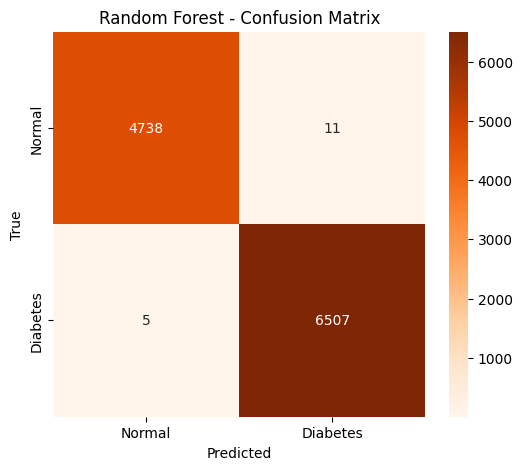

In [ ]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

rf_acc = accuracy_score(y_test, y_pred_rf)
print(f"\nRandom Forest Test Accuracy: {rf_acc*100:.2f}%")
print("\nRandom Forest Classification Report:\n", classification_report(y_test, y_pred_rf))

plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d',
            cmap="Oranges", xticklabels=["Normal","Diabetes"], yticklabels=["Normal","Diabetes"])
plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


Logistic Regression Test Accuracy: 98.68%

Logistic Regression Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.98      0.98      4749
           1       0.99      0.99      0.99      6512

    accuracy                           0.99     11261
   macro avg       0.99      0.99      0.99     11261
weighted avg       0.99      0.99      0.99     11261



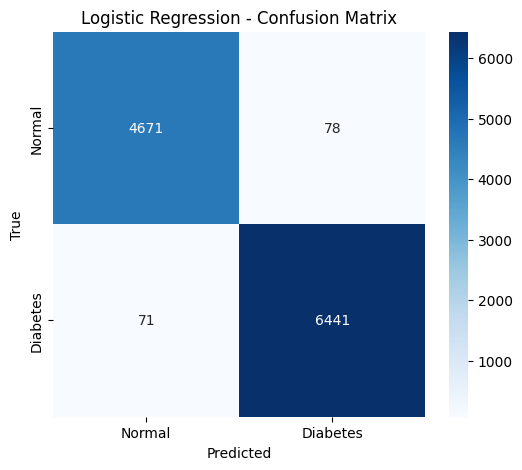

In [ ]:
log_reg = LogisticRegression(max_iter=2000)
log_reg.fit(X_train_scaled, y_train)   # Use scaled data
y_pred_lr = log_reg.predict(X_test_scaled)

lr_acc = accuracy_score(y_test, y_pred_lr)
print(f"\nLogistic Regression Test Accuracy: {lr_acc*100:.2f}%")
print("\nLogistic Regression Classification Report:\n", classification_report(y_test, y_pred_lr))

plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d',
            cmap="Blues", xticklabels=["Normal","Diabetes"], yticklabels=["Normal","Diabetes"])
plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()